# Target Variables

Exploratory review of the punctuality and quality targets that a ranking model could learn from.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


In [2]:
enriched = load_enriched_tasks()
on_time_balance = (
    pd.to_numeric(enriched["ON_TIME"], errors="coerce")
    .value_counts(dropna=False, normalize=True)
    .rename_axis("ON_TIME")
    .reset_index(name="share")
)
display(on_time_balance)

quality_stats = enriched["QUALITY_EVALUATION"].agg(["count", "mean", "median", "std", "min", "max"]).to_frame("value")
display(quality_stats)

high_quality_balance = (
    pd.to_numeric(enriched["HIGH_QUALITY_8"], errors="coerce")
    .value_counts(dropna=False, normalize=True)
    .rename_axis("HIGH_QUALITY_8")
    .reset_index(name="share")
)
display(high_quality_balance)

,ON_TIME,share
0,1.0,0.758237
1,0.0,0.241761
2,NaN,0.000002


,value
count,997933.000000
mean,7.042846
median,7.000000
std,1.463400
min,0.000000
max,10.000000


,HIGH_QUALITY_8,share
0,0,0.589253
1,1,0.410747


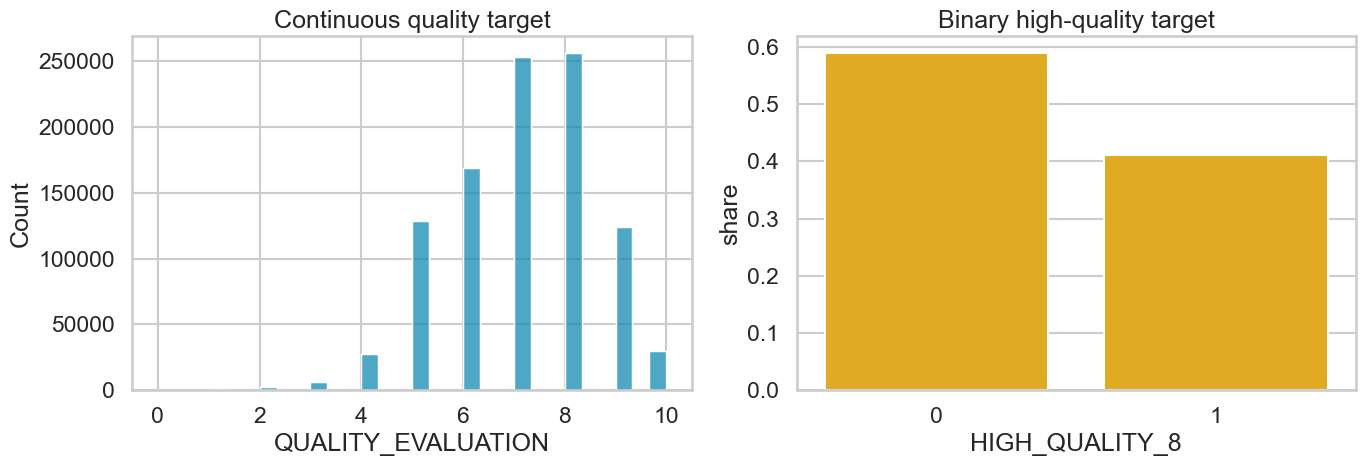

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(enriched["QUALITY_EVALUATION"].dropna(), bins=30, ax=axes[0], color="#118ab2")
axes[0].set_title("Continuous quality target")
sns.barplot(data=high_quality_balance, x="HIGH_QUALITY_8", y="share", ax=axes[1], color="#ffb703")
axes[1].set_title("Binary high-quality target")
plt.tight_layout()
plt.show()

In [4]:
scored_tasks = (
    enriched.groupby("TRANSLATOR")["QUALITY_EVALUATION"]
    .count()
    .rename("scored_tasks")
    .reset_index()
    .sort_values("scored_tasks", ascending=False)
)
display(scored_tasks.head(20))
unreliable = scored_tasks.loc[scored_tasks["scored_tasks"] < 5].copy()
display(pd.DataFrame([{"metric": "Translators with <5 scored tasks", "value": len(unreliable)}]))
display(unreliable.head(30))

,TRANSLATOR,scored_tasks
522,Isaias Venancio,65209
971,Xoana,46436
439,Gala,44533
512,Inocencio Lucas,31950
240,Casiano,26149
721,Markel,18538
782,Nieves Leocadia,18375
167,Ascension,17036
801,Oscar,16064
669,Luis Felipe,15122


,metric,value
0,Translators with <5 scored tasks,322


,TRANSLATOR,scored_tasks
400,Ezequiel,4
845,Primo Candida,4
420,Ferran,4
198,Beltran,4
853,Raimundo Guadalupe,4
862,Rigobert,4
864,Rita,4
743,Mehmet,4
8,Abril,4
105,Ana Lucia,4


,metric,value
0,Task-level correlation between ON_TIME and QUA...,0.023
1,Translator-level correlation between ON_TIME a...,0.110


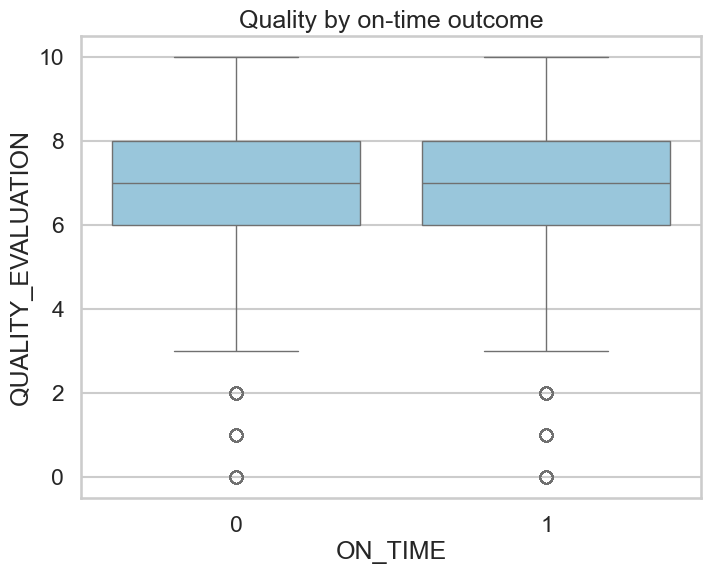

In [5]:
valid_target = enriched[["ON_TIME", "QUALITY_EVALUATION"]].dropna().copy()
valid_target["ON_TIME"] = pd.to_numeric(valid_target["ON_TIME"], errors="coerce")
task_level_corr = valid_target["ON_TIME"].corr(valid_target["QUALITY_EVALUATION"])

translator_level = (
    enriched.groupby("TRANSLATOR")
    .agg(on_time_rate=("ON_TIME", lambda s: pd.to_numeric(s, errors="coerce").mean()), avg_quality=("QUALITY_EVALUATION", "mean"))
    .dropna()
    .reset_index()
)
translator_corr = translator_level["on_time_rate"].corr(translator_level["avg_quality"])
display(
    pd.DataFrame(
        [
            {"metric": "Task-level correlation between ON_TIME and QUALITY_EVALUATION", "value": round(task_level_corr, 3)},
            {"metric": "Translator-level correlation between ON_TIME and QUALITY_EVALUATION", "value": round(translator_corr, 3)},
        ]
    )
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=valid_target.assign(ON_TIME=valid_target["ON_TIME"].astype(int)),
    x="ON_TIME",
    y="QUALITY_EVALUATION",
    color="#8ecae6",
)
plt.title("Quality by on-time outcome")
plt.show()